In [1]:
from pathlib import Path
import datetime
import json

import torch
import torch.nn.functional as F
from jaxtyping import Int, Float
import matplotlib.pyplot as plt

# custom utils
from muutils.misc import shorten_numerical_to_str
from trnbl import TrainingManager

# from trnbl.loggers.local import LocalLogger
from trnbl.loggers.tensorboard import TensorBoardLogger


from attention_motifs.train import contrastive_loss
from attention_motifs.dataset.dataset import CollectedAttentionPatternDataloader
from attention_motifs.dataset.util import AttentionPatternMetadata
from attention_motifs.vit_ae import VitAEConfig, VitAE

f:\projects\attention-motifs\.venv\Lib\site-packages\trnbl\loggers\base.py:17: UserWarning: GPUtil not available: No module named 'GPUtil'
  warnings.warn(f"GPUtil not available: {e}")


In [2]:
# magic autoreload
%load_ext autoreload
%autoreload 2

In [3]:
ACTIVATIONS_PATH = "../data/activations/small"

TRAIN_LOADER_DATASET = CollectedAttentionPatternDataloader.read(ACTIVATIONS_PATH)
# VAL_LOADER_DATASET = CollectedAttentionPatternDataloader.read(
# 	"../data/activations/pile_5_val"
# )
print(json.dumps(TRAIN_LOADER_DATASET.summary_short(), indent=2))

{
  "n_total_samples": 56440,
  "n_prompts": 83,
  "n_datasets": 9,
  "config": {
    "prompts_config": {
      "name": "pile_5",
      "source_path": "../data/pile_5.jsonl",
      "char_len_min": 64,
      "char_len_max": 256
    },
    "model_names": [
      "pythia-14m",
      "gpt2-small",
      "meta-llama/Llama-3.2-1B"
    ],
    "token_len_min": 16,
    "prompt_token_len_tolerance": 16,
    "raw_scores": false
  },
  "dataset_shapes_summary": [
    "(10120, 64, 64)",
    "(40760, 48, 48)",
    "(48, 80, 80)",
    "(2384, 32, 32)",
    "(680, 16, 16)",
    "(144, 112, 112)",
    "(1872, 128, 128)",
    "(288, 144, 144)",
    "(144, 96, 96)"
  ]
}


In [4]:
BATCH_SIZE: int = 16
N_TRAIN_BATCHES: int = 10
N_VAL_BATCHES: int = 10

In [5]:
TRAIN_LOADER = TRAIN_LOADER_DATASET.dataloader(
	BATCH_SIZE, shuffle=True, max_batches=N_TRAIN_BATCHES
)
# VAL_LOADER = VAL_LOADER_DATASET.dataloader(
# 	BATCH_SIZE, shuffle=True, max_batches=N_VAL_BATCHES
# )

print(f"Train loader: {len(TRAIN_LOADER)} batches, {len(TRAIN_LOADER.dataset)} samples")

Train loader: 10 batches, 160 samples


AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=5, idx_head=15, n_ctx=48, prompt_hash=2191276236)


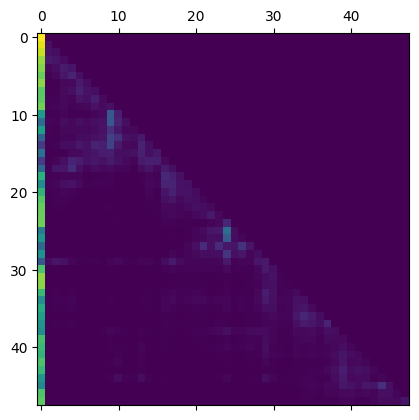

In [6]:
x_mat, x_meta = next(
	iter(TRAIN_LOADER_DATASET.dataloader(10, shuffle=True, max_batches=1))
)
x_mat.shape
print(x_meta[0])
plt.matshow(x_mat[0])

In [7]:
TRAIN_LOADER: torch.utils.data.DataLoader
VAL_LOADER: torch.utils.data.DataLoader | None = None

PROJECT_NAME: str = "vit-ae"
CHECKPT_INTERVAL: str = "1/2 run"
EVAL_INTERVAL: str = "1/2 run"
DEVICE: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [8]:
# set up model
MODEL: VitAE = VitAE(
	VitAEConfig(
		d_latent=128,
		num_epochs=1,
	)
)
MODEL_CONFIG: VitAEConfig = MODEL.config
model_n_params: int = sum(p.numel() for p in MODEL.parameters())
print(
	f"model has {model_n_params} ({shorten_numerical_to_str(model_n_params)}) parameters"
)
MODEL = MODEL.to(DEVICE)
MODEL.train()

# set up optimizer and lr scheduler
OPTIMIZER: torch.optim.Optimizer
LR_SCHEDULER: torch.optim.lr_scheduler._LRScheduler
OPTIMIZER, LR_SCHEDULER = MODEL_CONFIG.get_optim_and_lrs(MODEL)

model has 235280 (235K) parameters


In [9]:
# for name, param in MODEL.named_parameters():
# 	print(f"{name = }, {param.device = }, {param.requires_grad = }, {param.shape = }")

import pandas as pd

df = pd.DataFrame(
	[
		{
			"name": name,
			"device": param.device,
			"requires_grad": param.requires_grad,
			"shape": param.shape,
		}
		for name, param in MODEL.named_parameters()
	]
)

# set width for pandas display
pd.set_option("display.max_colwidth", 100)

display(df)

,name,device,requires_grad,shape
0,encoder.patch_embed.proj.weight,cuda:0,True,"(64, 1, 4, 4)"
1,encoder.patch_embed.proj.bias,cuda:0,True,"(64,)"
2,encoder.patch_embed.pos_embeds.0.weight,cuda:0,True,"(64, 64)"
3,encoder.patch_embed.pos_embeds.1.weight,cuda:0,True,"(64, 64)"
4,encoder.blocks.0.norm1.weight,cuda:0,True,"(64,)"
...,...,...,...,...
59,decoder.blocks.1.mlp.2.bias,cuda:0,True,"(64,)"
60,decoder.norm.weight,cuda:0,True,"(64,)"
61,decoder.norm.bias,cuda:0,True,"(64,)"
62,decoder.head.weight,cuda:0,True,"(16, 64)"


In [10]:
# init cuda memory history
# torch.cuda.memory._record_memory_history(max_entries=1000000)

# setup logger
LOGGER: TensorBoardLogger = TensorBoardLogger(
	log_dir=Path("tb-logs-convAE"),
	name=PROJECT_NAME + datetime.datetime.now().strftime("-%Y-%m-%d-%H-%M-%S"),
	# metric_names=[
	# 	"train/loss",
	# 	"train/recon_loss",
	# 	"train/contrast_loss",
	# 	"val/loss",
	# 	"val/recon_loss",
	# 	"val/contrast_loss",
	# ],
	train_config=dict(
		model_config=MODEL.zanj_model_config.serialize(),
		model_str=str(MODEL),
		dataloader=dict(
			activations_path=ACTIVATIONS_PATH,
			batch_size=BATCH_SIZE,
			n_train_batches=N_TRAIN_BATCHES,
			n_val_batches=N_VAL_BATCHES,
		),
	),
)

with TrainingManager(
	model=MODEL,
	logger=LOGGER,
	# evals={
	# 	EVAL_INTERVAL: evaluation_step,
	# }.items(),
	checkpoint_interval=CHECKPT_INTERVAL,
) as tr:
	for epoch in tr.epoch_loop(range(MODEL_CONFIG.num_epochs), use_tqdm=False):
		patterns: Float[torch.Tensor, "*batch n_ctx n_ctx"]
		metadata: list[AttentionPatternMetadata]
		for patterns, metadata in tr.batch_loop(TRAIN_LOADER, use_tqdm=True):
			this_batch_size: int = len(metadata)

			# move to device, convert type, add channel dim
			patterns = patterns.to(DEVICE).to(torch.float32).unsqueeze(1)

			# reset gradients
			OPTIMIZER.zero_grad()

			# forward pass
			patterns_recon, embeddings = MODEL(patterns)

			# reconstruction loss
			recon_loss = F.mse_loss(patterns_recon, patterns)

			# compute "classes" for contrastive loss
			# classes is a tensor of the same shape as the batch, where each element is an integer
			classes: Int[torch.Tensor, " batch"] = (
				AttentionPatternMetadata.contrastive_classes(metadata).to(DEVICE)
			)

			# compute contrastive loss
			contrast_loss = contrastive_loss(embeddings, classes)

			# combined loss and backward pass
			total_loss = (
				MODEL_CONFIG.recon_weight * recon_loss
				+ MODEL_CONFIG.contrast_weight * contrast_loss
			)

			# backward pass
			total_loss.backward()
			OPTIMIZER.step()
			LR_SCHEDULER.step(epoch)

			# log metrics
			metrics: dict[str, float] = {
				"train/loss": total_loss.item() / this_batch_size,
				"train/recon_loss": recon_loss.item() / this_batch_size,
				"train/contrast_loss": contrast_loss.item() / this_batch_size,
				"lr": LR_SCHEDULER.get_last_lr()[0],
			}
			tr.batch_update(
				samples=len(metadata),
				**metrics,
			)

			# cleanup
			del (
				patterns,
				patterns_recon,
				embeddings,
				recon_loss,
				contrast_loss,
				total_loss,
			)


# torch.cuda.memory._dump_snapshot("CUDA_MEM_SNAPSHOP.pickle")
# torch.cuda.memory._record_memory_history(enabled=None)

starting training manager initialization
initialized training manager


epoch 1/1:   0%|          | 0/10 [00:00<?, ? batches/s]F:\projects\attention-motifs\attention_motifs\train.py:73: UserWarning: No positive pairs found in batch
  warnings.warn("No positive pairs found in batch")
epoch 1/1: 100%|██████████| 10/10 [00:11<00:00,  1.19s/ batches]

training complete


AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=5, idx_head=15, n_ctx=48, prompt_hash=2191276236)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


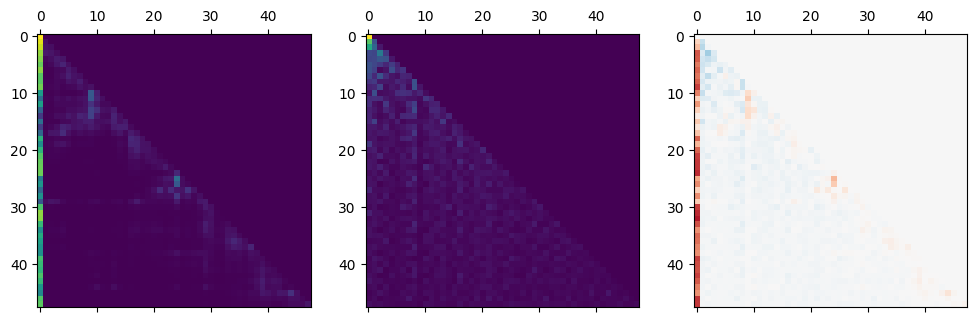

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=11, idx_head=21, n_ctx=48, prompt_hash=3837171290)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


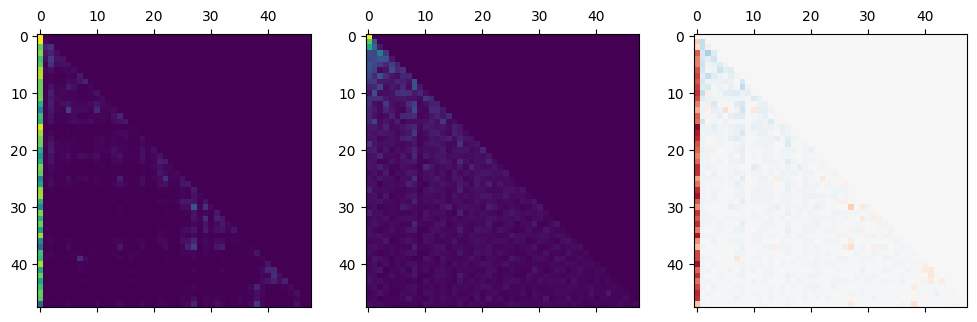

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=1, idx_head=13, n_ctx=48, prompt_hash=643793465)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


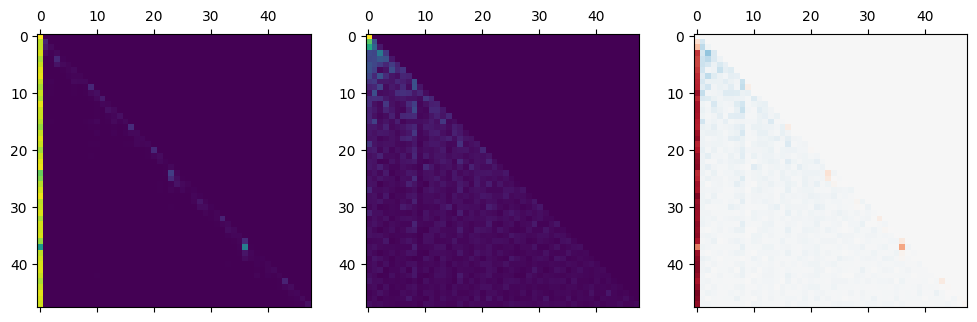

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=8, idx_head=11, n_ctx=48, prompt_hash=30820328)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


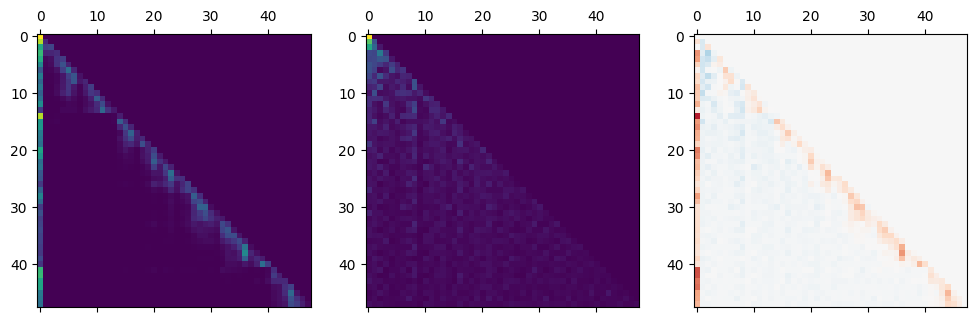

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=1, idx_head=20, n_ctx=48, prompt_hash=540450070)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


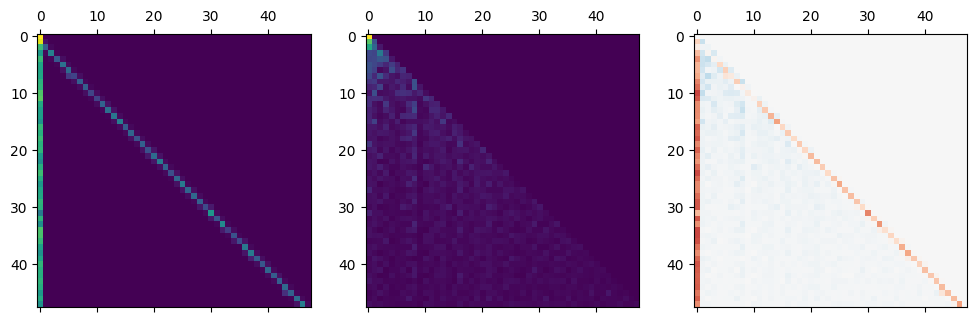

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=3, idx_head=16, n_ctx=48, prompt_hash=2073789921)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


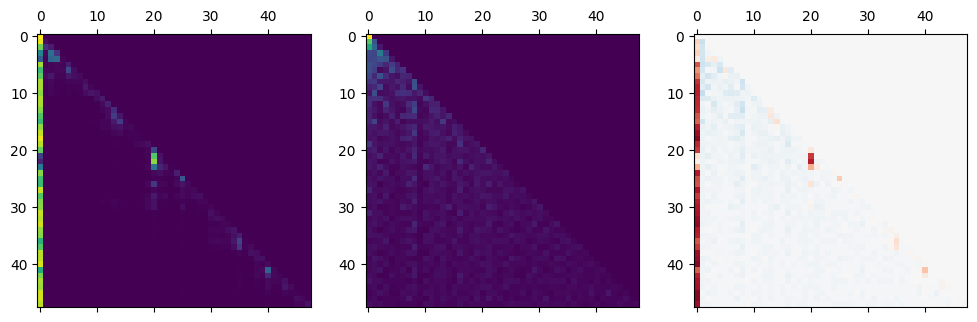

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=8, idx_head=11, n_ctx=48, prompt_hash=2951540061)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


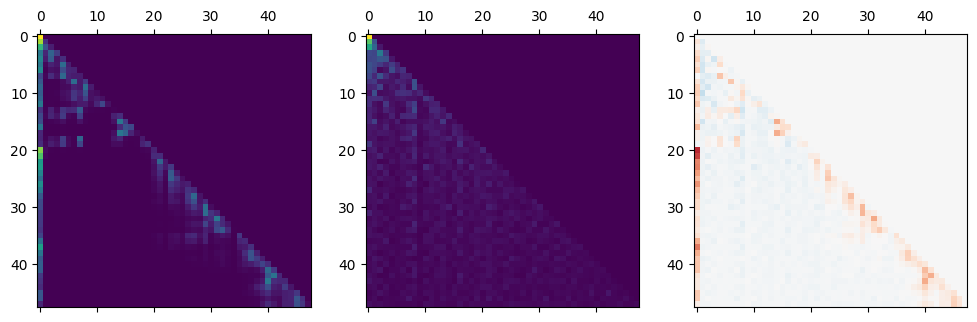

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=11, idx_head=1, n_ctx=48, prompt_hash=1021684937)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


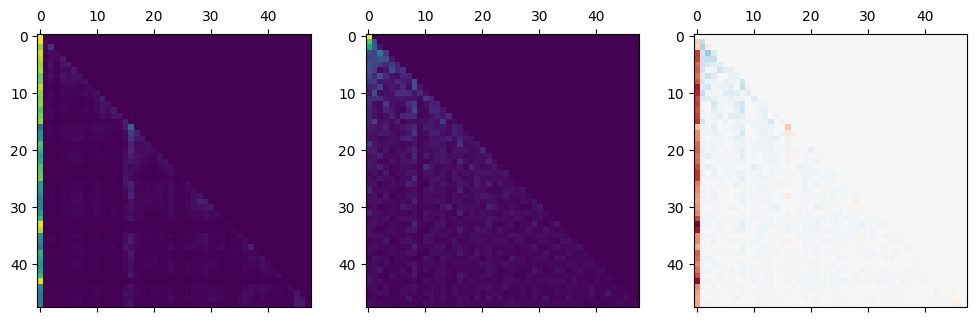

AttentionPatternMetadata(model_name='meta-llama/Llama-3.2-1B', idx_layer=8, idx_head=19, n_ctx=48, prompt_hash=1261011273)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


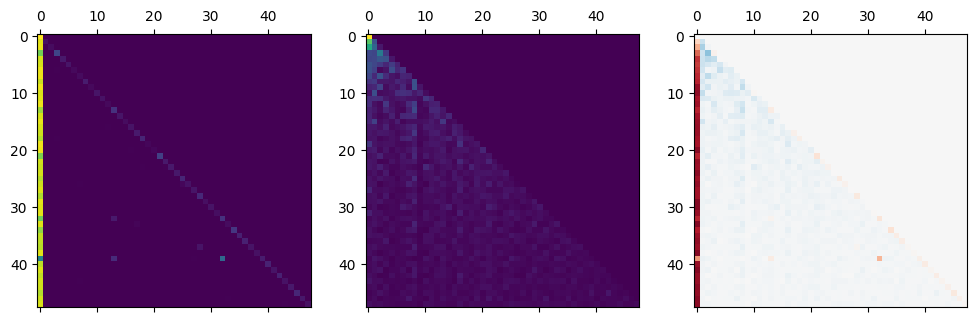

AttentionPatternMetadata(model_name='gpt2-small', idx_layer=1, idx_head=4, n_ctx=48, prompt_hash=1882179927)
x_mat.shape = torch.Size([10, 48, 48]), x_recon.shape = torch.Size([10, 1, 48, 48])
x_latent.shape = torch.Size([10, 128])


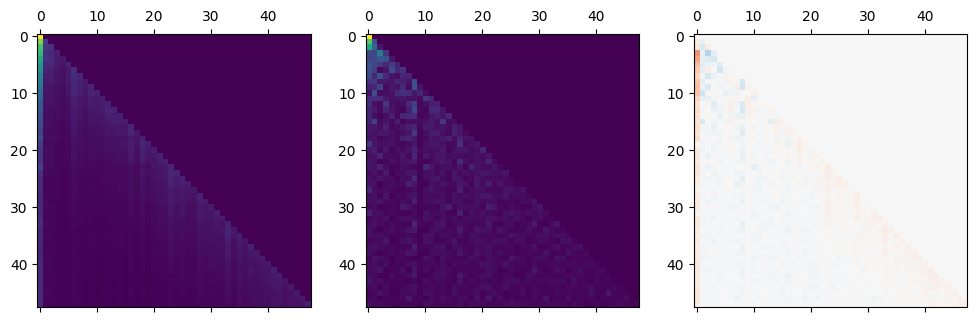

In [11]:
MODEL.eval()

eval_batchsize: int = len(x_meta)

for i in range(eval_batchsize):
	print(x_meta[i])
	x_recon, x_latent = MODEL(x_mat.to(DEVICE).to(torch.float32).unsqueeze(1))
	print(f"{x_mat.shape = }, {x_recon.shape = }")
	print(f"{x_latent.shape = }")

	x_recon_np = x_recon[i, 0].detach().cpu().numpy()

	fig, axs = plt.subplots(1, 3, figsize=(12, 4))
	axs[0].matshow(x_mat[i])
	axs[1].matshow(x_recon_np)
	axs[2].matshow(x_recon_np - x_mat[i].numpy(), cmap="RdBu", vmin=-1, vmax=1)
	plt.show()